# 6. Kernelised SVM

Applying the kernel trick so the SVM can separate classes that are not linearly
separable in the original feature space. The kernel here is the sigmoid
`tanh(sigma * <x, x'> + 1)`, and the model is fitted in the dual: coefficients
`u` over the training points plus a separate intercept `b`.

In [1]:
import sys
sys.path.append("..")

import numpy as np

from src.data import load_diabetes_data, prepare_diabetes_xy, diabetes_feature_names
from src.classification_metrics import accuracy, precision, f_score
from src.model_selection import get_rng, DEFAULT_SEED
from src.plotting import metrics_table
from src.results import record_result

rng = get_rng(DEFAULT_SEED)

from src.preprocessing import standardise, apply_standardisation
from src.svm import append_intercept, to_binary_labels
from src.svm_kernel import sigmoid_kernel, sgd_kernel, kernel_score

In [2]:
train_df, test_df = load_diabetes_data()
feature_names = diabetes_feature_names(train_df)

# The hinge loss needs labels in {-1, +1}.
X_raw, y = prepare_diabetes_xy(train_df, negative_label=-1)
X_test_raw, y_test = prepare_diabetes_xy(test_df, negative_label=-1)

X, mu, sigma = standardise(X_raw)
X_test = apply_standardisation(X_test_raw, mu, sigma)

# The intercept is appended as the LAST column, because the gradient identifies
# the bias by position (w[-1]) in order to leave it out of the penalty term.
X1 = append_intercept(X)
X_test1 = append_intercept(X_test)

# 0/1 copies for the shared classification metrics.
y_binary, y_test_binary = to_binary_labels(y), to_binary_labels(y_test)

print(f"train {X1.shape}, test {X_test1.shape}")

train (273, 14), test (117, 14)


## Sweeping the kernel width

The kernel matrix is built on the standardised features without the intercept
column, since the dual formulation carries its own bias term `b`.

In [3]:
sigma_values = [0.01, 0.1, 1, 2]
rows, row_labels = [], []

for sigma in sigma_values:
    K_train = sigmoid_kernel(X, X, sigma)
    u, b = sgd_kernel(K_train, y, batch_size=128, max_iterations=2000,
                      stop_criterion=0.001, learning_rate=1e-5, l=10, rng=rng)

    train_scores = kernel_score(u, b, X, X, y_binary, sigma)
    test_scores = kernel_score(u, b, X, X_test, y_test_binary, sigma)

    print(f"sigma = {sigma}  (intercept b = {b:.5f})")
    print(f"  train: accuracy {train_scores[0]:.4f}, precision {train_scores[1]:.4f}, F {train_scores[2]:.4f}")
    print(f"  test : accuracy {test_scores[0]:.4f}, precision {test_scores[1]:.4f}, F {test_scores[2]:.4f}")

    rows.append(list(test_scores))
    row_labels.append(f"sigma = {sigma}")

    record_result(f"Kernel SVM (sigma={sigma})", "train", accuracy=train_scores[0],
                  precision=train_scores[1], f_score=train_scores[2])
    record_result(f"Kernel SVM (sigma={sigma})", "test", accuracy=test_scores[0],
                  precision=test_scores[1], f_score=test_scores[2])

sigma = 0.01  (intercept b = -0.01890)
  train: accuracy 0.8388, precision 0.0000, F 0.0000
  test : accuracy 0.8632, precision 0.0000, F 0.0000


sigma = 0.1  (intercept b = -1.07350)
  train: accuracy 0.9304, precision 0.8788, F 0.7532
  test : accuracy 0.9231, precision 0.8182, F 0.6667


sigma = 1  (intercept b = -1.54550)
  train: accuracy 0.9853, precision 0.9762, F 0.9535
  test : accuracy 0.9231, precision 0.7333, F 0.7097


sigma = 2  (intercept b = -1.45410)
  train: accuracy 0.9927, precision 1.0000, F 0.9767
  test : accuracy 0.9060, precision 0.6471, F 0.6667


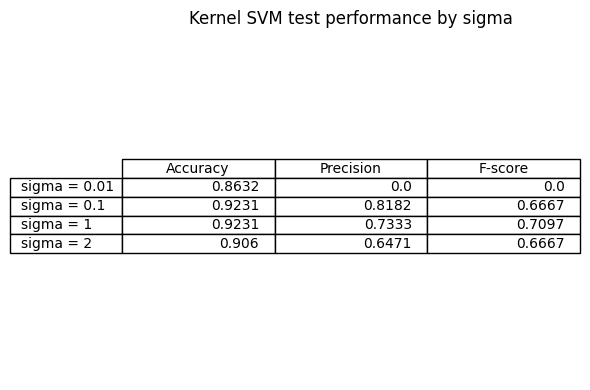

In [4]:
metrics_table(rows,
              columns=("Accuracy", "Precision", "F-score"),
              row_labels=row_labels,
              title="Kernel SVM test performance by sigma")

## Discussion

The kernelised SVM can represent boundaries a linear model cannot, so comparing
it against notebook 05 indicates whether non-linear structure is present in this
data.

On the test set, it is not. The linear SVM reaches 0.940 accuracy and 0.788
F-score on the test set; the best kernel width here (sigma = 1) manages 0.923 and
0.710. The kernel model fits the *training* set far more closely — 0.985 accuracy
at sigma = 1, rising to 0.993 at sigma = 2, against the linear model's 0.905 —
but none of that advantage carries over to unseen data.
A train-test gap that widens with sigma is the signature of overfitting rather
than of genuine non-linear structure being exploited, which is consistent with
what notebook 03 found on the regression side.

Note that at sigma = 0.01 the model predicts the negative class for every sample,
so precision and F-score report 0.0 — there are no positive predictions for it to
be right about. Its 0.863 test accuracy is just the base rate of non-diabetic
patients, which is why accuracy alone is a poor guide on this data.

**Next:** [07_model_comparison.ipynb](07_model_comparison.ipynb)